In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import mannwhitneyu, norm
from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kendalltau
from scipy.stats import anderson
import plotly.graph_objects as go
import plotly.express as px
from matplotlib.animation import FuncAnimation
rng = np.random.default_rng()
x = stats.uniform.rvs(size=75, random_state=rng)
sns.set(style="darkgrid")

#
df_todo = pd.read_csv('Banking_Transactions_USA_2023_2024.csv', nrows=5)  # solo 5 filas para ver
print(f'Columnas totales: {len(df_todo.columns)}')
print()
print('Lista de columnas:')
for i, col in enumerate(df_todo.columns, 1):
    print(f'  {i:>2}. {col}')

Columnas totales: 20

Lista de columnas:
   1. Transaction_ID
   2. Account_Number
   3. Transaction_Date
   4. Transaction_Amount
   5. Merchant_Name
   6. Transaction_Type
   7. Category
   8. City
   9. Country
  10. Payment_Method
  11. Customer_Age
  12. Customer_Gender
  13. Customer_Occupation
  14. Customer_Income
  15. Account_Balance
  16. Transaction_Status
  17. Fraud_Flag
  18. Discount_Applied
  19. Loyalty_Points_Earned
  20. Transaction_Description


In [2]:
#
df_bancos = pd.read_csv('Banking_Transactions_USA_2023_2024.csv')
mb_full = df_bancos.memory_usage(deep=True).sum() / 1024**2
print(f'Dataset completo: {df_bancos.shape} · {mb_full:.1f} MB')
print()

# Perfil de cada columna: tipo, NaN%, valores unicos
print(f'{"Columna":<30} {"Dtype":<12} {"NaN%":>7} {"Unicos":>8}')
print('-' * 65)
for col in df_bancos.columns:
    dtype = str(df_bancos[col].dtype)
    nan_pct = df_bancos[col].isna().mean() * 100
    n_uniq  = df_bancos[col].nunique()
    print(f'{col:<30} {dtype:<12} {nan_pct:>6.1f}% {n_uniq:>8,}')

Dataset completo: (5389, 20) · 5.3 MB

Columna                        Dtype           NaN%   Unicos
-----------------------------------------------------------------
Transaction_ID                 object          0.0%    5,389
Account_Number                 object          0.0%    5,389
Transaction_Date               object          0.0%    5,389
Transaction_Amount             float64         0.0%    5,369
Merchant_Name                  object          0.0%    4,880
Transaction_Type               object          0.0%        2
Category                       object          0.0%       14
City                           object          0.0%       10
Country                        object          0.0%        1
Payment_Method                 object          0.0%        5
Customer_Age                   int64           0.0%       53
Customer_Gender                object          0.0%        3
Customer_Occupation            object          0.0%      639
Customer_Income                float64   

In [3]:
#Cabecera: Primeros renglones de la base
df_bancos.head()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,IUPM04409079772781,2023-11-05 15:54:38,3198.94,Houston Group,Debit,Transport,Phoenix,USA,Online Transfer,55,Others,Quality manager,80466.03,350.28,Failed,No,True,304,Recently company detail form range a.
1,23b8c1e9-3924-46de-beb1-3b9046685257,BLAT22216107051843,2024-04-21 22:21:55,129.93,Anderson-Phillips,Credit,Grocery,Philadelphia,USA,Debit Card,26,Others,Civil Service fast streamer,145574.25,9797.81,Pending,Yes,False,383,Anything son baby power heart will not up.
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,UTXA55295806601382,2023-07-17 13:25:56,1378.77,Jensen Group,Credit,Shopping,New York,USA,Debit Card,29,Others,"Pilot, airline",33447.18,12399.85,Failed,Yes,False,497,Form world around green bar environment pattern.
3,972a8469-1641-4f82-8b9d-2434e465e150,XICF70493862044851,2023-06-27 16:09:52,1119.94,"Nelson, Gomez and Rodriguez",Credit,Healthcare,Dallas,USA,Online Transfer,60,Male,"Radiographer, therapeutic",108801.45,16057.64,Failed,Yes,True,495,Order evening source these opportunity trade i...
4,17fc695a-07a0-4a6e-8822-e8f36c031199,KOSW19711121259020,2024-03-26 23:45:31,3683.67,Caldwell Group,Credit,Entertainment,San Jose,USA,E-Wallet,29,Others,Diplomatic Services operational officer,100985.12,14940.54,Failed,Yes,True,292,Exactly politics door suggest.


In [4]:
#Últimos elementos de la base
df_bancos.tail()

,Transaction_ID,Account_Number,Transaction_Date,Transaction_Amount,Merchant_Name,Transaction_Type,Category,City,Country,Payment_Method,Customer_Age,Customer_Gender,Customer_Occupation,Customer_Income,Account_Balance,Transaction_Status,Fraud_Flag,Discount_Applied,Loyalty_Points_Earned,Transaction_Description
5384,31e43850-86a8-4b2b-9c69-ee49712c3126,LXVL92532425475957,2023-05-01 07:20:11,842.16,Navarro Group,Credit,Savings,Phoenix,USA,Cash,20,Male,"Loss adjuster, chartered",75036.50,8747.79,Pending,Yes,True,332,Sit could account happen organization hand act...
5385,5415668e-4f75-43d1-9610-7189016ff44c,MFJS29896187528828,2023-09-15 03:49:42,1996.73,Banks-Reed,Credit,Travel,Phoenix,USA,Credit Card,28,Male,Accommodation manager,107479.71,2698.54,Failed,Yes,True,60,Soldier per crime nothing improve structure ow...
5386,ea725584-5e6e-487a-a939-f79018177e4a,DOBF62458522431672,2024-11-30 00:58:14,1510.33,Brown PLC,Debit,Utilities,Dallas,USA,Credit Card,23,Male,"Administrator, education",33759.96,476.93,Success,No,True,475,Magazine reality share office doctor managemen...
5387,03539b9a-ebeb-4d98-80b7-10a640f66fde,BRHX88846108622659,2023-08-09 00:31:15,3732.02,Townsend-Bartlett,Debit,Savings,Chicago,USA,Cash,40,Female,Music therapist,32706.74,7167.05,Success,Yes,True,482,Probably ago western approach.
5388,a5b01639-0895-4db1-85e5-26e19b559178,CTJA66942505562975,2024-03-16 09:44:09,3763.38,"Molina, Smith and King",Debit,Utilities,Houston,USA,Debit Card,38,Male,Structural engineer,106270.94,2197.74,Success,Yes,False,152,Social suddenly lead.


In [5]:
#Resumen de las variables numéricas
summary = df_bancos.describe()
print(summary)

       Transaction_Amount  Customer_Age  Customer_Income  Account_Balance  \
count         5389.000000   5389.000000      5389.000000      5389.000000   
mean          2504.649200     44.023567     85802.754023     10096.510087   
std           1426.745115     15.239148     37343.604534      5732.846891   
min              5.460000     18.000000     20028.940000       101.720000   
25%           1283.340000     31.000000     53809.800000      5159.450000   
50%           2521.670000     44.000000     85636.380000     10077.780000   
75%           3715.920000     57.000000    118092.640000     15076.010000   
max           4999.540000     70.000000    149970.500000     19993.040000   

       Loyalty_Points_Earned  
count            5389.000000  
mean              249.897384  
std               145.378373  
min                 0.000000  
25%               122.000000  
50%               251.000000  
75%               377.000000  
max               500.000000  


In [6]:
#Resumen de las variables discretas
print(df_bancos.describe(include='object'))

                              Transaction_ID      Account_Number  \
count                                   5389                5389   
unique                                  5389                5389   
top     a5b01639-0895-4db1-85e5-26e19b559178  CTJA66942505562975   
freq                                       1                   1   

           Transaction_Date Merchant_Name Transaction_Type   Category  \
count                  5389          5389             5389       5389   
unique                 5389          4880                2         14   
top     2024-03-16 09:44:09     Smith PLC            Debit  Utilities   
freq                      1            10             2708        417   

           City Country Payment_Method Customer_Gender    Customer_Occupation  \
count      5389    5389           5389            5389                   5389   
unique       10       1              5               3                    639   
top     Chicago     USA       E-Wallet          Fe

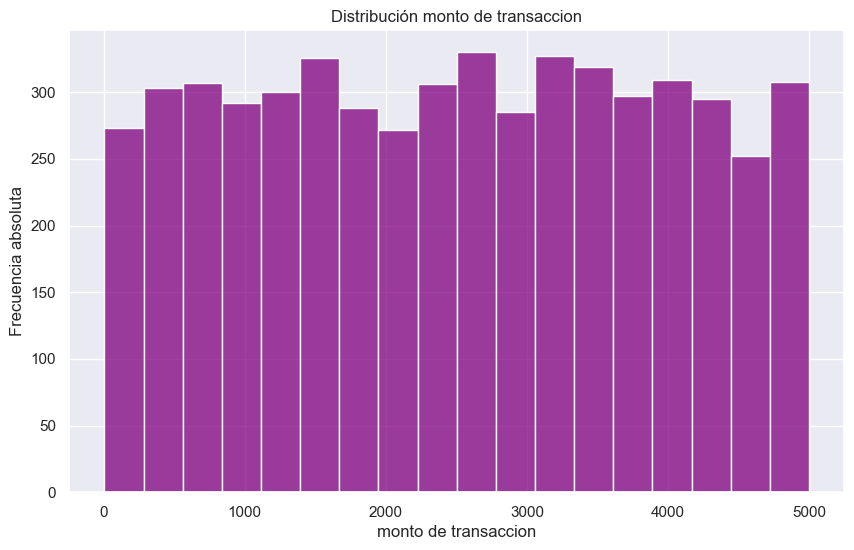

In [11]:
#Descripción gráfica: Histograma
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos, x='Transaction_Amount', color='purple')
plt.title('Distribución monto de transaccion')
plt.xlabel('monto de transaccion')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

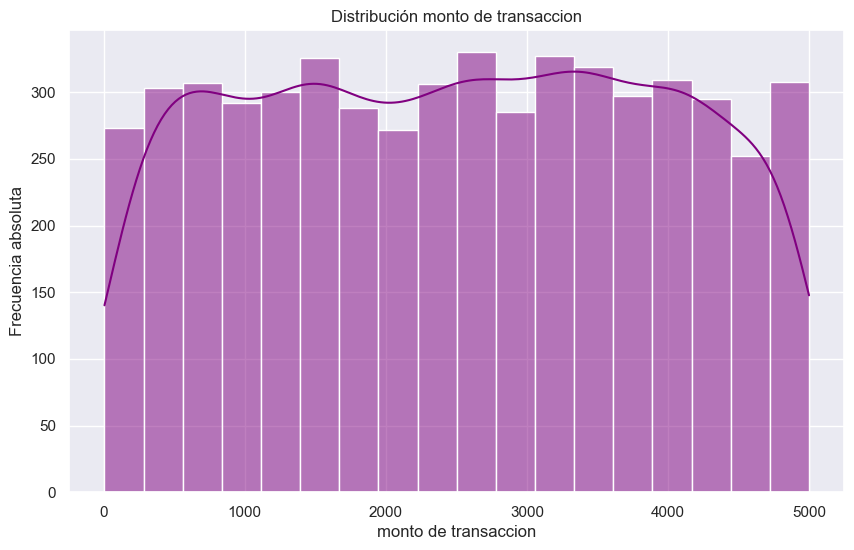

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos, x='Transaction_Amount', color='purple', kde=True)
plt.title('Distribución monto de transaccion')
plt.xlabel('monto de transaccion')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

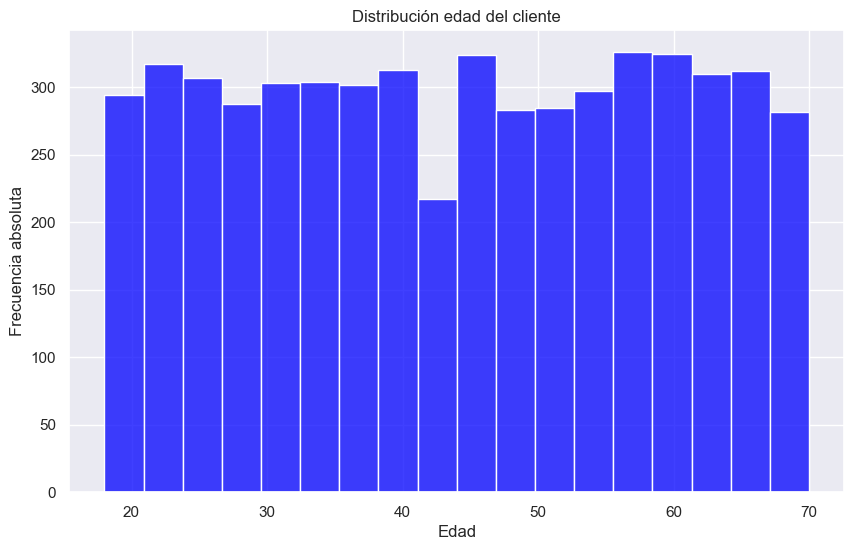

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_bancos, x='Customer_Age', color='blue') #bins controla el número de particiones
plt.title('Distribución edad del cliente')
plt.xlabel('Edad')
plt.ylabel('Frecuencia absoluta')
plt.grid(True)
plt.show()

In [19]:
df_bancos['logTransaction'] = np.log(df_bancos['Transaction_Amount'])

<Axes: xlabel='logTransaction', ylabel='Density'>

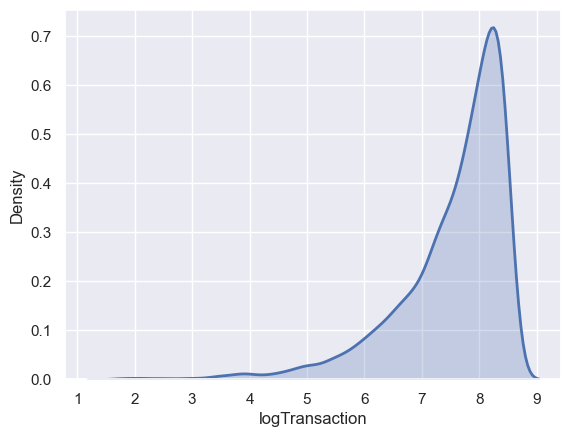

In [21]:
sns.kdeplot(x=df_bancos['logTransaction'], fill=True, linewidth=2)

In [24]:
tran_gof = stats.goodness_of_fit(stats.norm, df_bancos.logTransaction, statistic='ks', rng=rng)
tran_gof.statistic, tran_gof.pvalue
# se rechaza h0 por lo que no es una distribucion normal

(np.float64(0.15319203610495236), np.float64(0.0001))

In [27]:
weibull_gof = stats.goodness_of_fit(
    stats.weibull_min,
    df_bancos.logTransaction,
    statistic='ks',
    rng=rng
)

weibull_gof.statistic, weibull_gof.pvalue

/Users/valeria/anaconda3/envs/diplomado/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:2763: RuntimeWarning: overflow encountered in power
  return np.log(c) + sc.xlogy(c - 1, x) - pow(x, c)


KeyboardInterrupt: 

In [28]:
lognorm_gof = stats.goodness_of_fit(
    stats.lognorm,
    df_bancos.logTransaction,
    statistic='ks',
    rng=rng
)

lognorm_gof.statistic, lognorm_gof.pvalue

(np.float64(0.15317001893493298), np.float64(0.0001))

In [31]:
x = df_bancos['Transaction_Amount']

weibull_gof = stats.goodness_of_fit(
    stats.weibull_min,
    x,
    statistic='ks',
    rng=rng
)

print(weibull_gof.statistic)
print(weibull_gof.pvalue)

KeyboardInterrupt: 

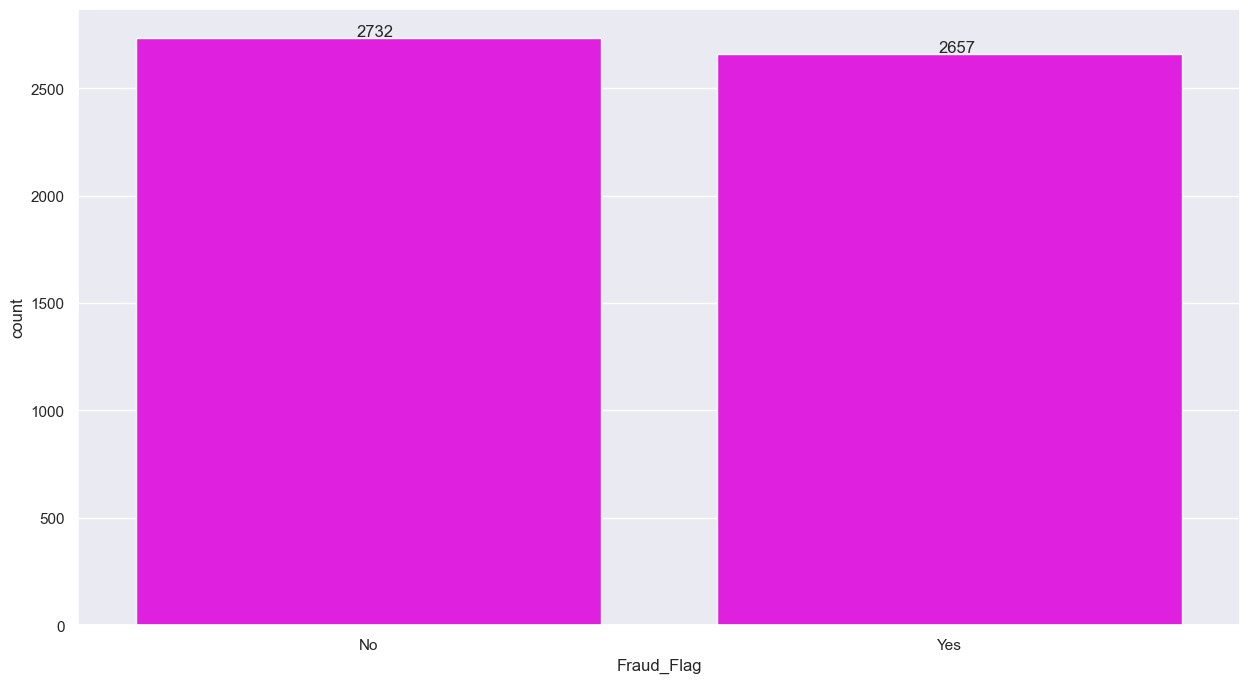

In [30]:
#Con valores encima de las barras
sns.set(rc={'figure.figsize':(15,8)})
ax=sns.countplot(x='Fraud_Flag',data=df_bancos,color='magenta')
for p in ax.patches:
    patch_height = p.get_height()
    if np.isnan(patch_height):
        patch_height = 0
    ax.annotate('{}'.format(int(patch_height)), (p.get_x()+0.38, patch_height+10))
plt.show()


Text(0.5, 1.0, 'Distribucion por region')

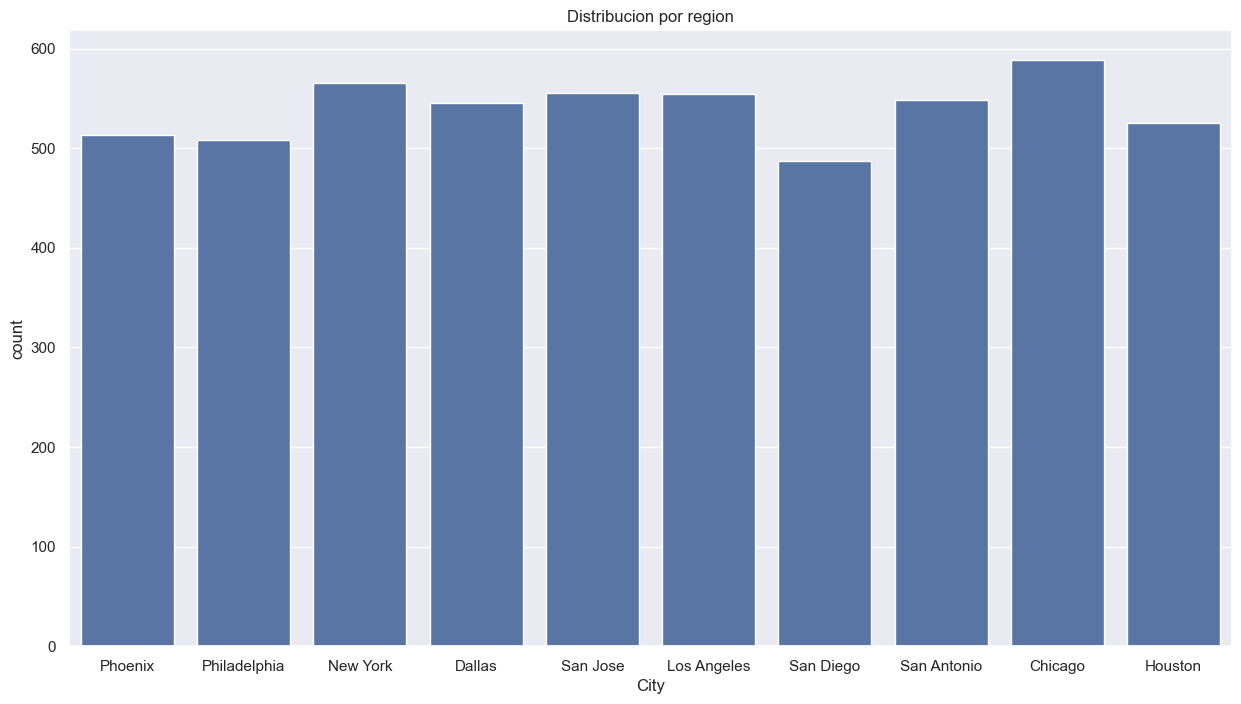

In [32]:
sns.countplot(data=df_bancos, x="City")
plt.title('Distribucion por region')

<Axes: xlabel='Transaction_Amount'>

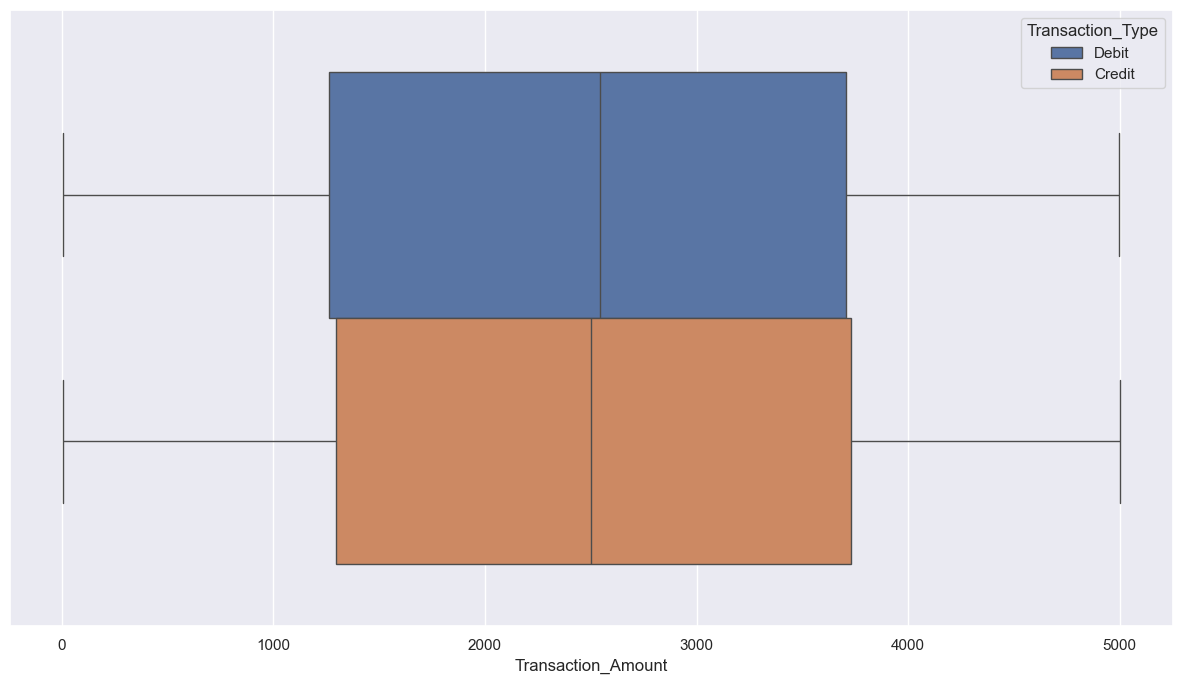

In [ ]:
#Comparación de poblaciones a través de box-plot: monto por tipo de transaccion
sns.boxplot(data=df_bancos, x="Transaction_Amount", hue="Transaction_Type")

#Los montos de


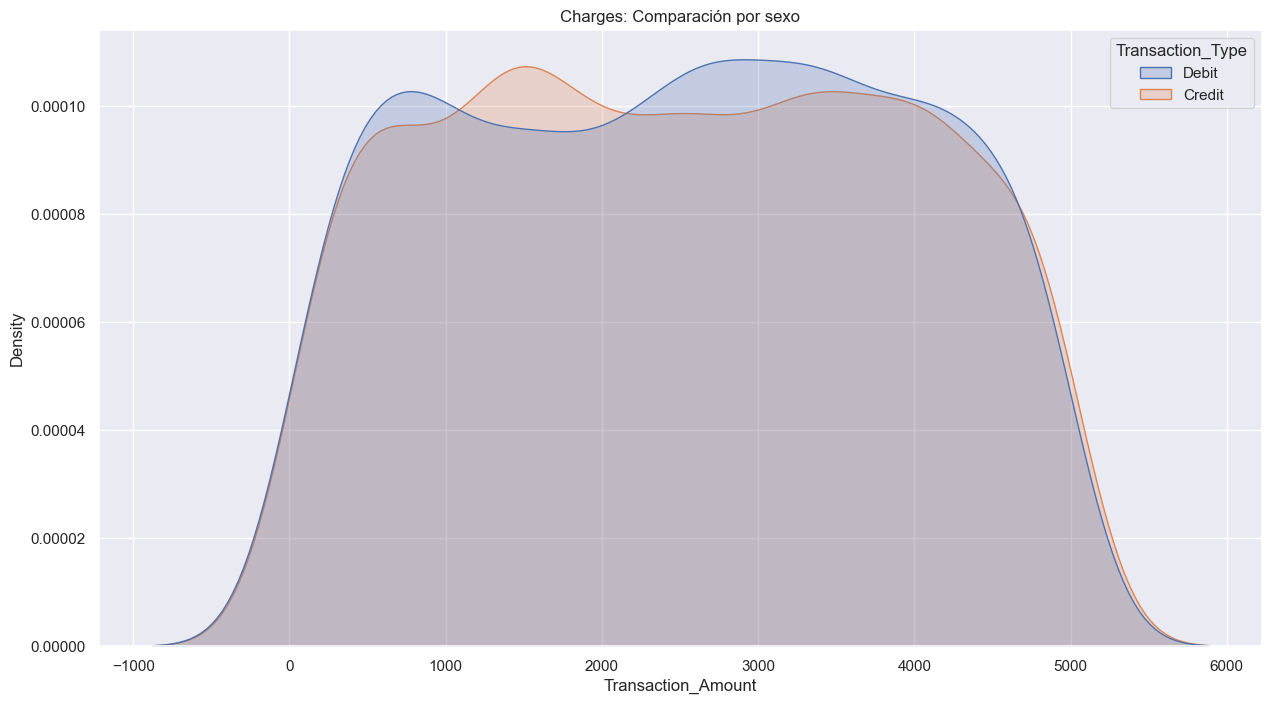

In [ ]:
sns.kdeplot(data=df_bancos, x="Transaction_Amount", hue="Transaction_Type", fill=True)
plt.title('Comparacion por tipo de transaccion')
plt.show()

In [ ]:
# Prueba de normalidad separado por tipo de transaccion
filtered_debit = df_bancos[(df_bancos['Transaction_Type'] == 'Debit')&(df_bancos['Transaction_Amount'])] 
filtered_credit = df_bancos[(df_bancos['Transaction_Type'] == 'Credit')&(df_bancos['Transaction_Amount'])] 

stat, p_value = mannwhitneyu(filtered_credit.Transaction_Amount,filtered_debit.Transaction_Amount,alternative='two-sided')
print("U Statistic:", stat)
print("P-value:", p_value)

U Statistic: 3628765.5
P-value: 0.981726011991257


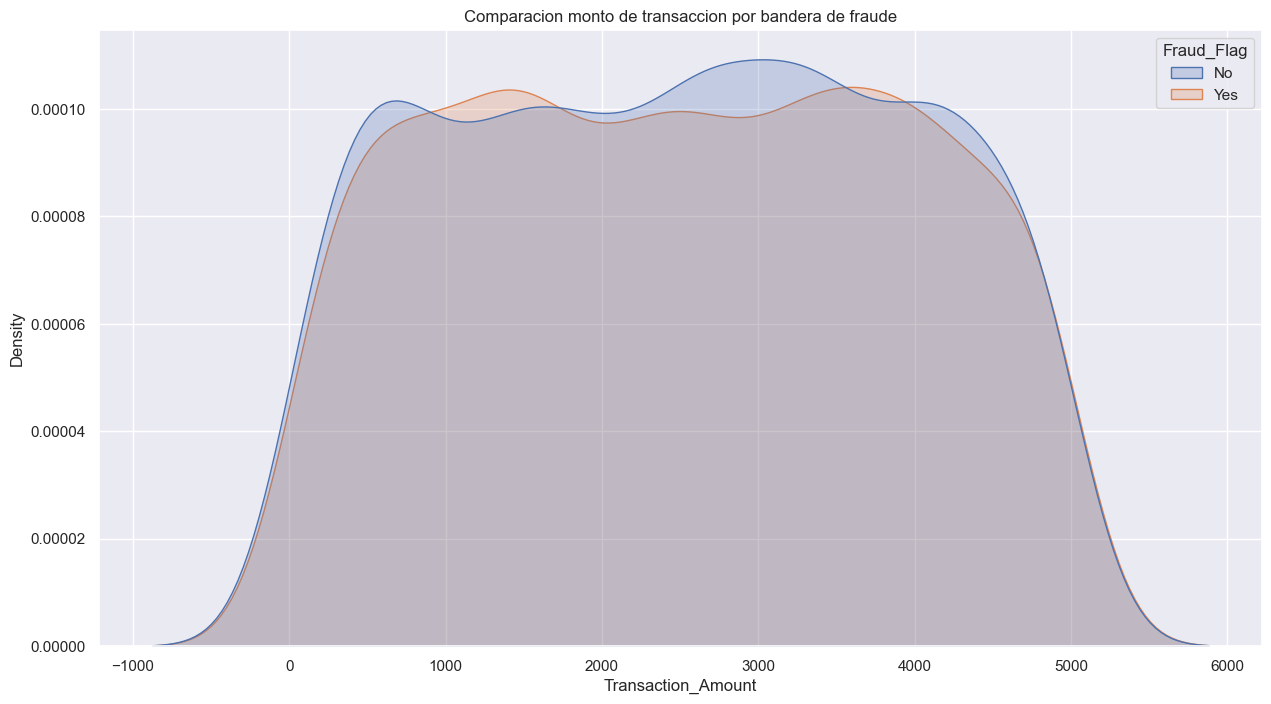

In [40]:
#Comparacion de monto de transaccion por bandera de fraude a travez de densidades
sns.kdeplot(data=df_bancos, x="Transaction_Amount", hue="Fraud_Flag", fill=True)
plt.title('Comparacion monto de transaccion por bandera de fraude')
plt.show()